<a href="https://colab.research.google.com/github/Christian2555-hub/sistema-abm-de-contactos/blob/main/Copia_de_Copia_de_Modelo_ABP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROYECTO ABP Rendimiento de Jugadores de Fútbol

## **PRESENTACIÓN DEL PROYECTO**

### **1. Tipo de Proyecto.** Tecnológico / de Investigación.  
Se trata de un proyecto de análisis de datos aplicado al deporte, con enfoque en métricas de rendimiento y salud de jugadores.

### **2. Abstract.**

Este proyecto analiza el rendimiento de jugadores de fútbol utilizando un conjunto de datos con información sobre edad, minutos jugados, distancia recorrida, pases, goles, asistencias, lesiones y nivel de fatiga. La motivación principal es identificar factores que influyen en el desempeño deportivo y en el riesgo de lesiones, con el fin de mejorar la planificación y gestión de los equipos. Mediante técnicas de análisis exploratorio de datos y visualización, se buscarán patrones y relaciones entre las variables estudiadas. Los resultados estarán orientados a entrenadores, preparadores físicos, analistas de rendimiento y directivos deportivos, brindando información útil para la toma de decisiones basada en datos.






### **3. Contexto Comercial y Analítico**

En el fútbol profesional, los clubes buscan mejorar el rendimiento de sus jugadores y reducir el riesgo de lesiones para obtener mejores resultados deportivos. En este contexto, el análisis de datos permite identificar patrones de desempeño y apoyar la toma de decisiones de entrenadores, preparadores físicos y directivos.

Este proyecto utiliza un enfoque de análisis descriptivo y exploratorio (EDA) sobre un dataset de 1.500 jugadores. Se analizarán variables como edad, minutos jugados, distancia recorrida, pases, goles, asistencias, lesiones y nivel de fatiga. Como limitación, se debe considerar que los datos son simulados y no pertenecen a una competición real.

Hipótesis de trabajo:

Los jugadores con mayor fatiga tienen más probabilidades de lesionarse.
Los jugadores jóvenes presentan mejor rendimiento físico que los veteranos.
Existen diferencias en el rendimiento ofensivo entre los equipos.

### **4. Fuente de Datos**

El dataset proviene de un archivo CSV con 1.500 registros de jugadores.
El origen: Es una integración de datos simulados de rendimiento deportivo.
Estructuras: variables numéricas (edad, minutos, distancia, pases, goles, asistencias, fatiga) y categóricas (equipo, lesión).
Sesgos: dataset ficticio, no representa una liga real.

### **5. Preguntas / Hipótesis a Resolver mediante el Análisis de Datos** [Problemática / Necesidades]

¿Qué equipo tiene mejor rendimiento ofensivo (goles + asistencias)?

¿Existe relación entre fatiga y lesiones?

¿Los jugadores jóvenes (<22 años) muestran mayor rendimiento físico que los veteranos (>30 años)?

¿Qué variables explican mejor el rendimiento ofensivo de un jugador?

### **6. Objetivos** [Generales / Específicos]

Objetivo General:  
Analizar el rendimiento de jugadores de fútbol mediante técnicas de estadística descriptiva y exploratoria para identificar patrones de desempeño y riesgos asociados a la fatiga y lesiones.

Objetivos Específicos:

Calcular estadísticas descriptivas de las principales variables (goles, asistencias, minutos, distancia).

Evaluar la relación entre fatiga y lesiones.

Comparar el rendimiento ofensivo entre equipos y grupos de edad.

Generar visualizaciones que permitan comunicar hallazgos de manera clara y efectiva.

## **IMPORTACION DE DATA**

In [ ]:
import pandas as pd

# Importar dataset
from google.colab import drive
import os
drive.mount("/content/drive")
df = pd.read_csv("football_data_integration.csv")

# Ver estructura
df.info()
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player_id       500 non-null    object 
 1   age             500 non-null    int64  
 2   team            500 non-null    object 
 3   minutes_played  500 non-null    int64  
 4   distance_km     500 non-null    float64
 5   passes          500 non-null    int64  
 6   goals           500 non-null    int64  
 7   assists         500 non-null    int64  
 8   injury          500 non-null    int64  
 9   fatigue_level   500 non-null    int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 39.2+ KB


,player_id,age,team,minutes_played,distance_km,passes,goals,assists,injury,fatigue_level
0,P1000,21,Team A,74,8.42,48,1,2,1,5
1,P1001,26,Team A,65,8.61,12,1,0,1,2
2,P1002,35,Team A,19,6.16,53,2,1,0,4
3,P1003,31,Team C,56,5.44,71,2,2,1,4
4,P1004,22,Team C,51,5.50,23,3,1,0,7


## EDA - Análisis exploratorio de datos



### **1. Conocer los datos**

En esta etapa se realizó una exploración inicial del conjunto de datos con el objetivo de comprender su estructura y contenido.

El dataset está compuesto por 1.500 registros de jugadores de fútbol y contiene información relacionada con el rendimiento deportivo, la carga física y el estado de salud de los jugadores.

In [ ]:
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player_id       500 non-null    object 
 1   age             500 non-null    int64  
 2   team            500 non-null    object 
 3   minutes_played  500 non-null    int64  
 4   distance_km     500 non-null    float64
 5   passes          500 non-null    int64  
 6   goals           500 non-null    int64  
 7   assists         500 non-null    int64  
 8   injury          500 non-null    int64  
 9   fatigue_level   500 non-null    int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 39.2+ KB


,player_id,age,team,minutes_played,distance_km,passes,goals,assists,injury,fatigue_level
0,P1000,21,Team A,74,8.42,48,1,2,1,5
1,P1001,26,Team A,65,8.61,12,1,0,1,2
2,P1002,35,Team A,19,6.16,53,2,1,0,4
3,P1003,31,Team C,56,5.44,71,2,2,1,4
4,P1004,22,Team C,51,5.50,23,3,1,0,7


Diccionario de datos:

Variable------------- Descripción

player_id-------------Identificador único del jugador

age-------------------Edad del jugador

team------------------Equipo al que pertenece

minutes_player--------Minutos jugados

distance_km-----------Distancia recorrida en kilómetros

passes----------------Cantidad de pases realizados

goals-----------------Goles anotados

assists---------------Asistencias realizadas

injury----------------Lesión (0 = No, 1 = Sí)

fatigue_level---------Nivel de fatiga (1 a 10)



Se identificó que el conjunto de datos contiene variables numéricas y categóricas. La variable player_id funciona como identificador único y no aporta información para el análisis estadístico del rendimiento. Las variables restantes permiten estudiar aspectos físicos, ofensivos y de salud de los jugadores.

# **2. Limpieza de datos**

La limpieza de datos tuvo como objetivo asegurar la calidad y consistencia de la información antes de realizar los análisis.

In [ ]:
df.isnull().sum()

,0
player_id,0
age,0
team,0
minutes_played,0
distance_km,0
passes,0
goals,0
assists,0
injury,0
fatigue_level,0


Se verificó la existencia de valores nulos en cada columna para determinar si era necesario aplicar técnicas de imputación o eliminación de registros.

In [ ]:
df.duplicated().sum()

np.int64(0)

Se comprobó que las variables numéricas y categóricas estuvieran correctamente definidas.

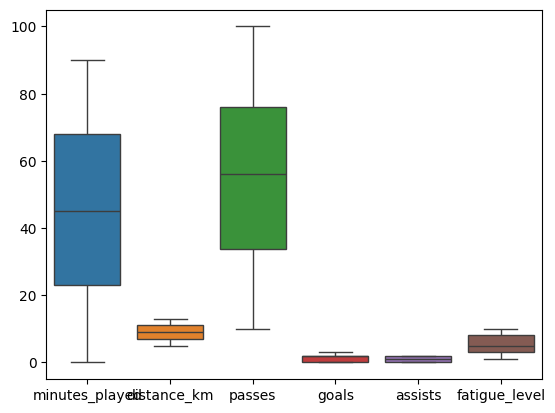

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.boxplot(data=df[['minutes_played',
                     'distance_km',
                     'passes',
                     'goals',
                     'assists',
                     'fatigue_level']])
plt.show()

Se analizaron posibles valores atípicos que pudieran representar errores de carga o casos excepcionales.

In [ ]:
## Normalización de variables categóricas

df['team'].unique()

array(['Team A', 'Team C', 'Team D', 'Team B'], dtype=object)

Se verificó que los nombres de los equipos estuvieran escritos de manera uniforme para evitar categorías duplicadas.

### **3. Análisis descriptivo**

En esta etapa se calcularon estadísticas descriptivas para resumir la información contenida en el dataset.

In [ ]:
df[['age',
    'minutes_played',
    'distance_km',
    'passes',
    'goals',
    'assists',
    'fatigue_level']].describe()

,age,minutes_played,distance_km,passes,goals,assists,fatigue_level
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.00000
mean,26.086000,45.068000,9.056940,54.982000,1.48600,1.026000,5.29800
std,5.027639,26.045962,2.363493,25.621604,1.11188,0.828672,2.82793
min,18.000000,0.000000,5.010000,10.000000,0.00000,0.000000,1.00000
25%,22.000000,23.000000,6.935000,33.750000,0.00000,0.000000,3.00000
50%,26.000000,45.000000,9.150000,56.000000,2.00000,1.000000,5.00000
75%,30.000000,68.000000,11.080000,76.000000,2.00000,2.000000,8.00000
max,35.000000,90.000000,12.980000,100.000000,3.00000,2.000000,10.00000


Variables analizadas


Edad de los jugadores.

Minutos disputados.

Distancia recorrida.


Cantidad de pases.

Goles anotados.

Asistencias realizadas.

Nivel de fatiga.

INTERPRETACION

A partir de las medidas de tendencia central y dispersión fue posible conocer el comportamiento general de las variables. Se analizaron los promedios, valores mínimos y máximos, así como la variabilidad presente en cada indicador de rendimiento.

También se evaluó la distribución de goles y asistencias para identificar diferencias en el desempeño ofensivo de los jugadores.

### **4. Visualización**

La visualización permitió representar gráficamente la información para detectar patrones y comunicar resultados de manera más clara.

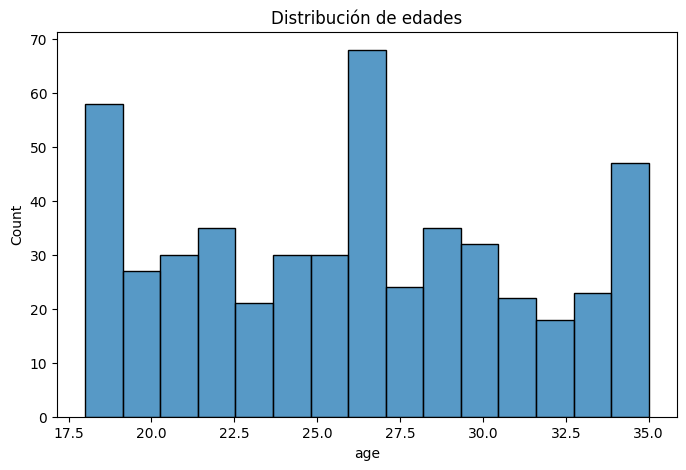

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=15)
plt.title("Distribución de edades")
plt.show()

Permite observar la concentración de jugadores según rangos de edad.

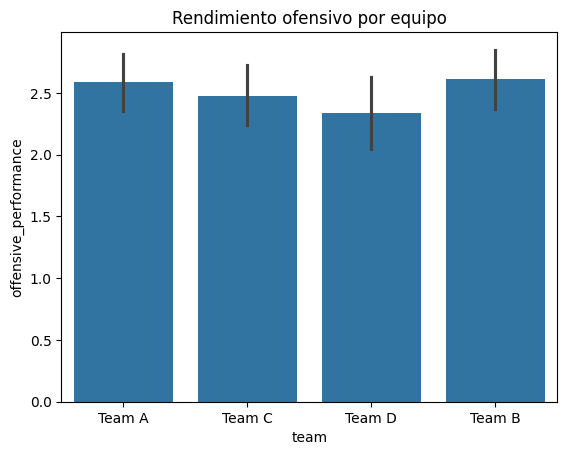

In [ ]:
## RENDIMIENTO POR EQUIPO

df['offensive_performance'] = df['goals'] + df['assists']

sns.barplot(
    data=df,
    x='team',
    y='offensive_performance'
)
plt.title("Rendimiento ofensivo por equipo")
plt.show()

Permite identificar qué equipo presenta el mayor promedio de participación ofensiva.

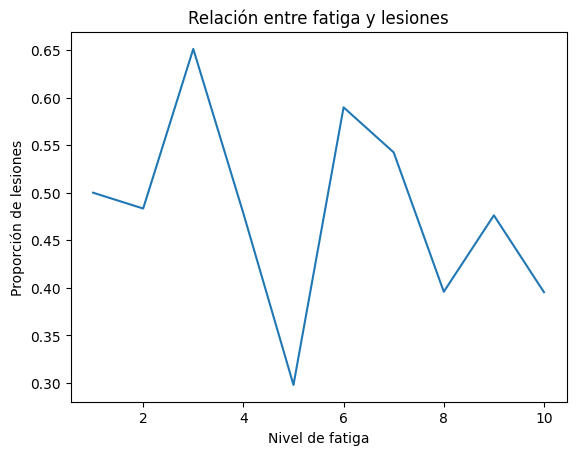

In [ ]:
injury_rate = df.groupby('fatigue_level')['injury'].mean()

sns.lineplot(
    x=injury_rate.index,
    y=injury_rate.values
)

plt.title("Relación entre fatiga y lesiones")
plt.ylabel("Proporción de lesiones")
plt.xlabel("Nivel de fatiga")
plt.show()

Permite evaluar si el aumento de la fatiga se relaciona con una mayor probabilidad de sufrir lesiones.

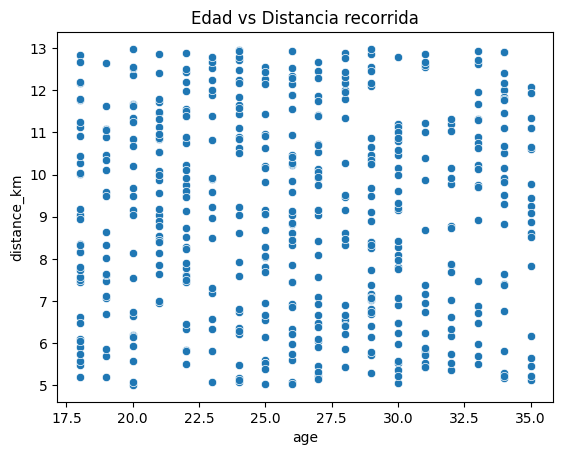

In [ ]:
sns.scatterplot(
    data=df,
    x='age',
    y='distance_km'
)

plt.title("Edad vs Distancia recorrida")
plt.show()

Ayuda a analizar si los jugadores más jóvenes presentan un mayor rendimiento físico en comparación con los veteranos.

CONCLUSIONES

El dataset presenta información suficiente para analizar rendimiento deportivo y riesgo de lesiones.
Los indicadores físicos y ofensivos muestran variabilidad entre jugadores y equipos.
La relación entre fatiga y lesiones puede representar un factor importante para la planificación deportiva.
Las visualizaciones permiten detectar patrones que serán profundizados en las siguientes etapas del proyecto.

Esta redacción suele ajustarse muy bien a lo que los profesores esperan en un ABP porque no se limita al código: explica qué se hizo, por qué se hizo y qué aporta cada análisis.